In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

In [2]:
t1 = pd.read_csv("../results/t1.csv", header=None, sep=";").rename(columns={0: 'name', 1: 'time'})
t2 = pd.read_csv("../results/t2.csv", header=None, sep=";").rename(columns={0: 'name', 1: 'time'})
t4 = pd.read_csv("../results/t4.csv", header=None, sep=";").rename(columns={0: 'name', 1: 'time'})
t8 = pd.read_csv("../results/t8.csv", header=None, sep=";").rename(columns={0: 'name', 1: 'time'})
t16 = pd.read_csv("../results/t16.csv", header=None, sep=";").rename(columns={0: 'name', 1: 'time'})

In [3]:
t1_g = t1.groupby('name')
t1_d = t1_g.describe()
t2_g = t2.groupby('name')
t2_d = t2_g.describe()
t4_g = t4.groupby('name')
t4_d = t4_g.describe()
t8_g = t8.groupby('name')
t8_d = t8_g.describe()
t16_g = t16.groupby('name')
t16_d = t16_g.describe()

In [14]:
t1_d

time                                                        \
               count       mean       std        min        25%        50%   
name                                                                         
conv1          999.0   0.167849  0.001451   0.165328   0.166768   0.167560   
conv10         999.0   0.437453  0.004802   0.416371   0.434779   0.436323   
conv10_back    999.0   0.041820  0.000370   0.041071   0.041531   0.041770   
conv11         999.0   0.053901  0.000958   0.052814   0.053026   0.053292   
conv11_back    999.0   0.006246  0.000114   0.006069   0.006150   0.006203   
conv12         999.0   0.022499  0.000270   0.022216   0.022294   0.022416   
conv12_back    999.0   0.003196  0.000069   0.003063   0.003161   0.003191   
conv13         999.0   0.009650  0.000516   0.009102   0.009227   0.009313   
conv13_back    999.0   0.002106  0.000062   0.001919   0.002079   0.002113   
conv1_back     999.0   0.010093  0.000221   0.009749   0.010006   0.010077   
conv2          999.0   5.895657  0.060115   5.839373   5.867952   5.873653   
conv2_back     999.0   0.568737  0.007427   0.499053   0.566740   0.567812   
conv3          999.0   1.565395  0.015100   1.526646   1.558918   1.561053   
conv3_back     999.0   0.127047  0.002270   0.124605   0.125540   0.126144   
conv4          999.0   2.976270  0.030060   2.930257   2.963737   2.966993   
conv4_back     999.0   0.258691  0.006606   0.233920   0.259582   0.260601   
conv5          999.0   0.785699  0.009879   0.769911   0.777261   0.786786   
conv5_back     999.0   0.064659  0.000861   0.063663   0.064146   0.064478   
conv6          999.0   1.433680  0.014134   1.413406   1.421744   1.431438   
conv6_back     999.0   0.121194  0.001796   0.119177   0.119913   0.120772   
conv7          999.0   1.322403  0.012978   1.302675   1.311941   1.319428   
conv7_back     999.0   0.114843  0.002661   0.111641   0.112440   0.114164   
conv8          999.0   0.330357  0.004318   0.313183   0.328430   0.329684   
conv8_back     999.0   0.031064  0.000277   0.030540   0.030863   0.031020   
conv9          999.0   0.544763  0.005594   0.519398   0.541257   0.543135   
conv9_back     999.0   0.050802  0.000469   0.049990   0.050471   0.050711   
dense1         999.0   0.001273  0.000080   0.001184   0.001222   0.001251   
dense1_back    999.0   0.002252  0.000039   0.002131   0.002226   0.002250   
dense2         999.0   0.001942  0.000064   0.001843   0.001920   0.001938   
dense2_back    999.0   0.004323  0.000583   0.004007   0.004166   0.004210   
dense3         999.0   0.000011  0.000064   0.000007   0.000008   0.000009   
dense3_back    999.0   0.000031  0.000308   0.000018   0.000020   0.000021   
maxpool1       999.0   0.378456  0.007855   0.367255   0.378282   0.379785   
maxpool1_back  999.0   0.057338  0.000674   0.055977   0.056854   0.057278   
maxpool2       999.0   0.171578  0.002258   0.167899   0.170518   0.170844   
maxpool2_back  999.0   0.027162  0.001999   0.010539   0.026999   0.027317   
maxpool3       999.0   0.064079  0.000833   0.063225   0.063420   0.063654   
maxpool3_back  999.0   0.006586  0.003112   0.003903   0.004448   0.004550   
maxpool4       999.0   0.015373  0.000146   0.015247   0.015295   0.015320   
maxpool4_back  999.0   0.000951  0.000144   0.000621   0.000859   0.000940   
maxpool5       999.0   0.000246  0.000007   0.000238   0.000241   0.000245   
maxpool5_back  999.0   0.000012  0.000003   0.000008   0.000010   0.000013   
vgg16          999.0  16.178665  0.149580  16.003176  16.101011  16.123538   
vgg16_back     999.0   1.505974  0.017745   1.410441   1.496908   1.505941   

                                     
                     75%        max  
name                                 
conv1           0.168593   0.179341  
conv10          0.439535   0.468209  
conv10_back     0.042083   0.045766  
conv11          0.054780   0.060310  
conv11_back     0.006355   0.006699  
conv12          0.022582   0.024247  
conv12_

In [4]:
layers = pd.unique(t1["name"]).tolist()
layers
layers_f = list(filter(lambda x: x[-1] != "k", layers))
layers_t = list(filter(lambda x: x[-1] == "k", layers))
seq_f = layers_f[:-1]
seq_t = layers_t[:-1]

In [5]:
t1.loc[t1["name"].isin(seq_f)]

,name,time
0,conv1,0.172168
1,conv2,5.850612
2,maxpool1,0.378134
3,conv3,1.549563
4,conv4,2.943846
...,...,...
43928,conv13,0.009287
43929,maxpool5,0.000243
43930,dense1,0.001239
43931,dense2,0.001947


In [6]:
seq_f

['conv1',
 'conv2',
 'maxpool1',
 'conv3',
 'conv4',
 'maxpool2',
 'conv5',
 'conv6',
 'conv7',
 'maxpool3',
 'conv8',
 'conv9',
 'conv10',
 'maxpool4',
 'conv11',
 'conv12',
 'conv13',
 'maxpool5',
 'dense1',
 'dense2',
 'dense3']

[Text(1, 0, 'conv1'),
 Text(2, 0, 'conv2'),
 Text(3, 0, 'maxpool1'),
 Text(4, 0, 'conv3'),
 Text(5, 0, 'conv4'),
 Text(6, 0, 'maxpool2'),
 Text(7, 0, 'conv5'),
 Text(8, 0, 'conv6'),
 Text(9, 0, 'conv7'),
 Text(10, 0, 'maxpool3'),
 Text(11, 0, 'conv8'),
 Text(12, 0, 'conv9'),
 Text(13, 0, 'conv10'),
 Text(14, 0, 'maxpool4'),
 Text(15, 0, 'conv11'),
 Text(16, 0, 'conv12'),
 Text(17, 0, 'conv13'),
 Text(18, 0, 'maxpool5'),
 Text(19, 0, 'dense1'),
 Text(20, 0, 'dense2'),
 Text(21, 0, 'dense3')]

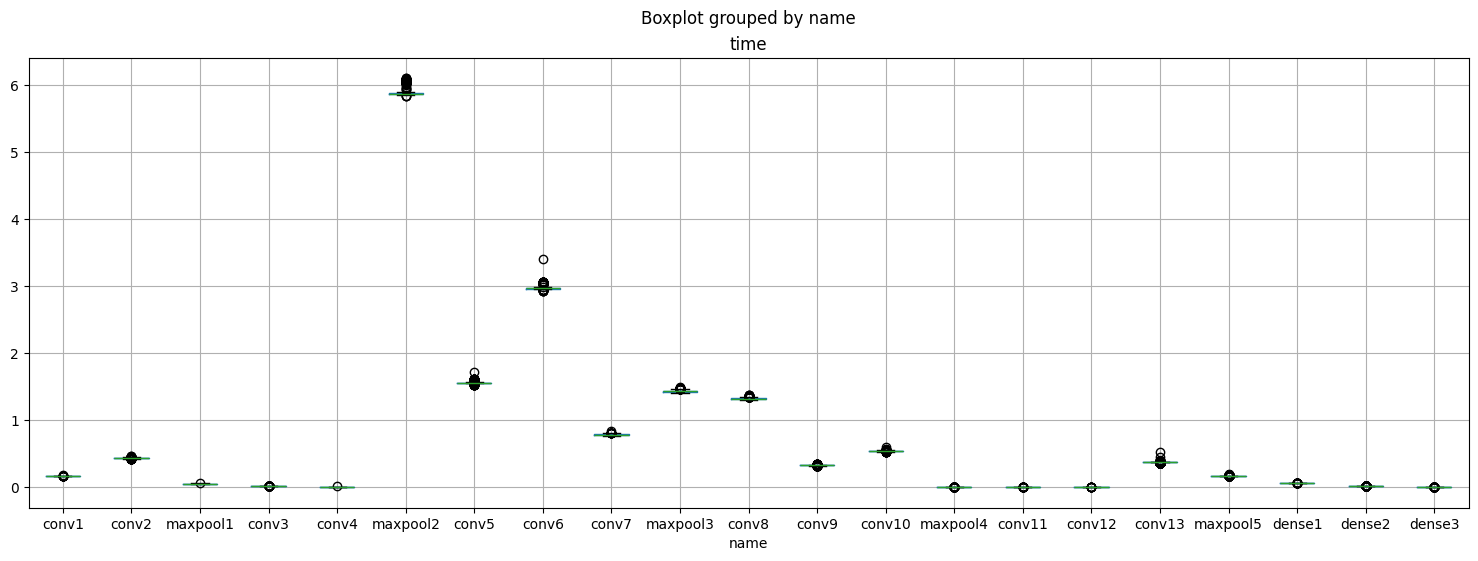

In [7]:
fig, ax = plt.subplots(figsize=(18,6))
t1.loc[t1["name"].isin(seq_f)].boxplot(column="time", by="name", ax=ax)
ax.set_xticklabels(seq_f)

{'whiskers': [<matplotlib.lines.Line2D at 0x7f5d1f3aa620>,
 'caps': [<matplotlib.lines.Line2D at 0x7f5d1f3aab60>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f5d1f3aa380>],
 'medians': [<matplotlib.lines.Line2D at 0x7f5d1f3ab0a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f5d1f3ab340>],
 'means': []}

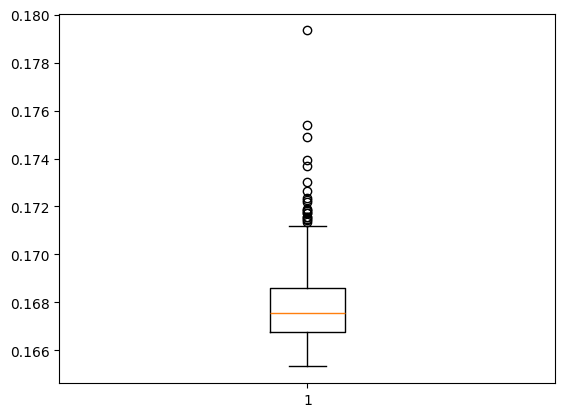

In [8]:
plt.boxplot(t1.loc[t1["name"] == "conv1"]["time"])

[Text(1, 0, 'conv1'),
 Text(2, 0, 'conv2'),
 Text(3, 0, 'maxpool1'),
 Text(4, 0, 'conv3'),
 Text(5, 0, 'conv4'),
 Text(6, 0, 'maxpool2'),
 Text(7, 0, 'conv5'),
 Text(8, 0, 'conv6'),
 Text(9, 0, 'conv7'),
 Text(10, 0, 'maxpool3'),
 Text(11, 0, 'conv8'),
 Text(12, 0, 'conv9'),
 Text(13, 0, 'conv10'),
 Text(14, 0, 'maxpool4'),
 Text(15, 0, 'conv11'),
 Text(16, 0, 'conv12'),
 Text(17, 0, 'conv13'),
 Text(18, 0, 'maxpool5'),
 Text(19, 0, 'dense1'),
 Text(20, 0, 'dense2'),
 Text(21, 0, 'dense3')]

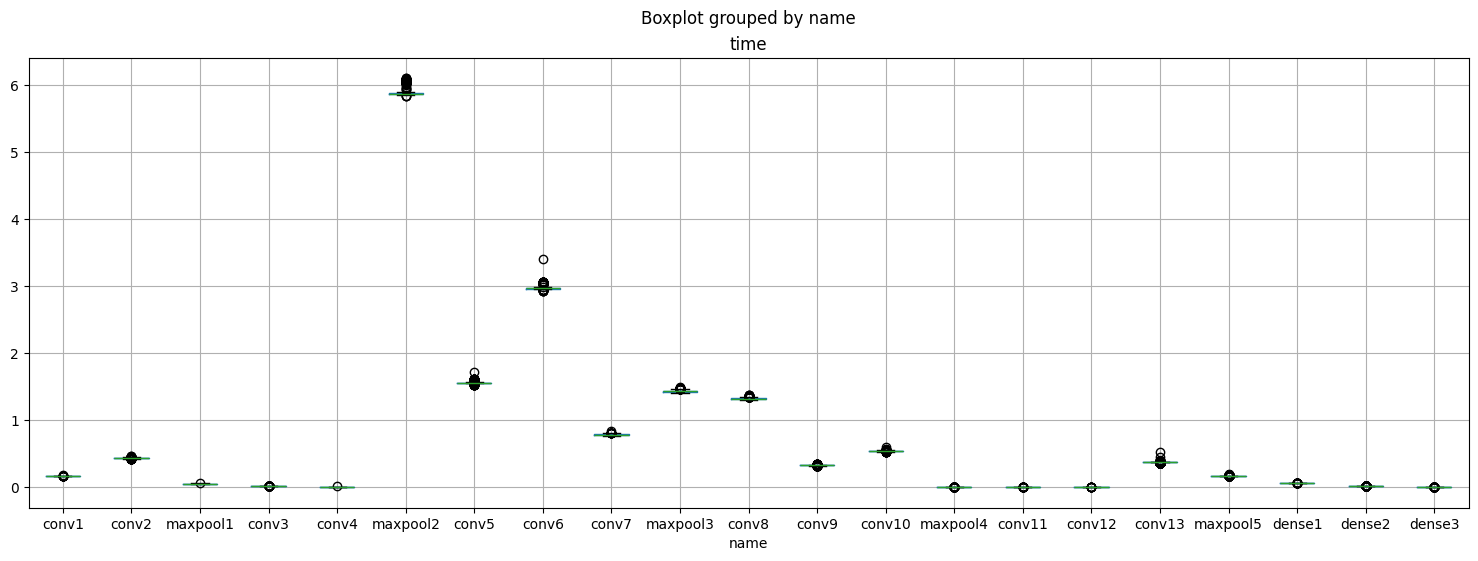

In [9]:
fig, ax = plt.subplots(figsize=(18,6))
t1.loc[t2["name"].isin(seq_f)].boxplot(column="time", by="name", ax=ax)
ax.set_xticklabels(seq_f)

In [10]:
t1_g.mean().loc['vgg16'].values

array([16.1786649])

In [11]:
avgs_f = np.stack([t1_g.mean().loc['vgg16'].values,
                t2_g.mean().loc['vgg16'].values,
                t4_g.mean().loc['vgg16'].values,
                t8_g.mean().loc['vgg16'].values,
                t16_g.mean().loc['vgg16'].values]).flatten()
avgs_b = np.stack([t1_g.mean().loc['vgg16_back'].values,
                t2_g.mean().loc['vgg16_back'].values,
                t4_g.mean().loc['vgg16_back'].values,
                t8_g.mean().loc['vgg16_back'].values,
                t16_g.mean().loc['vgg16_back'].values]).flatten()

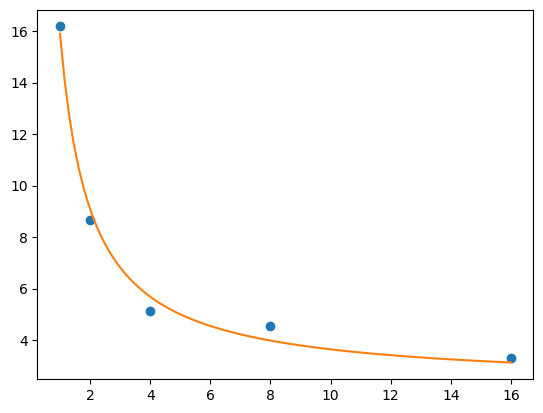

In [12]:
threads = [2**x for x in range(5)]

plt.plot(threads, avgs_f, 'o')

def func(x, a, b):
    return a / x + b

xdata = np.linspace(1, 16, 100)

popt, pcov = curve_fit(func, threads, avgs_f)
plt.plot(xdata, func(xdata, *popt))

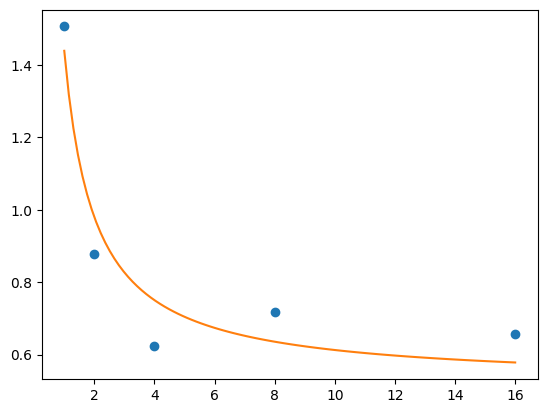

In [13]:
threads = [2**x for x in range(5)]

plt.plot(threads, avgs_b, 'o')

def func(x, a, b):
    return a / x + b

xdata = np.linspace(1, 16, 100)

popt, pcov = curve_fit(func, threads, avgs_b)
plt.plot(xdata, func(xdata, *popt))